In [ ]:
import wandb
import pandas as pd

api = wandb.Api()
setups = {
    "TAXI" :{"obj": "ep_info/Objective", "name": "taxi_nominal"},
    "TAXI_ROBUST1" :{"obj": "ep_info/Objective", "name": "taxi_optimistic"},
    "TAXI_ROBUST2" :{"obj": "ep_info/Objective", "name": "taxi_pessimistic"},
    "VSS" :{"obj": "ep_info/Goal", "name": "vss_nominal"},
    "ROBUSTNESS_TEST1" :{"obj": "ep_info/Goal", "name": "vss_minus25"},
    "ROBUSTNESS_TEST2" :{"obj": "ep_info/Goal", "name": "vss_plus25"},
}

for env, setup in setups.items():
    runs = api.runs("goncamateus/DyLam", filters={"config.env": env, "config.setup": "Dylam"})

    dfs = []
    for run in runs:
        hist = run.history(keys=[setup["obj"], "_step"])
        hist["seed"] = run.config.get("seed", run.id)
        dfs.append(hist)

    pd.concat(dfs).to_csv(f"{setup['name']}.csv", index=False)

Saved robustness_curves.pdf and robustness_curves.png.


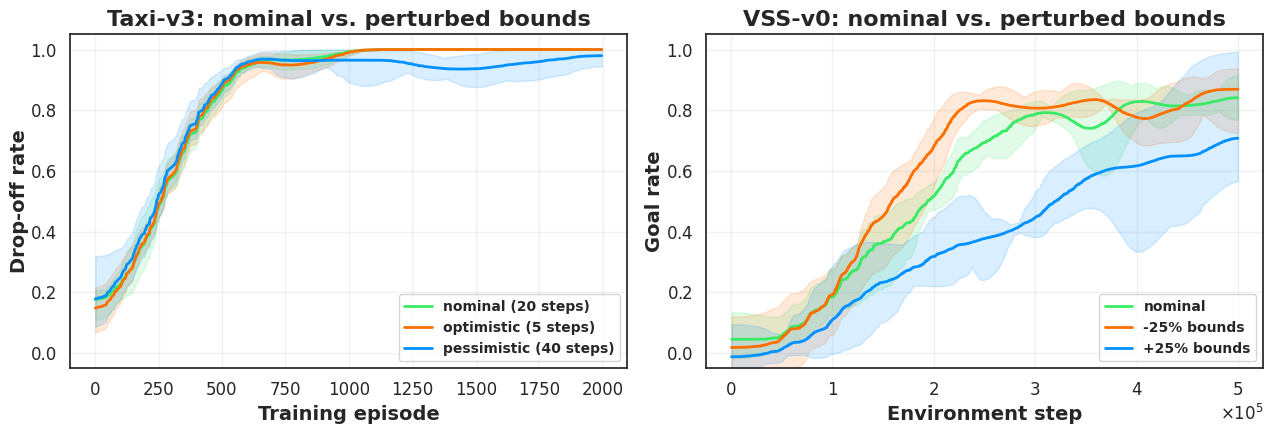

In [27]:
"""
Robustness curves for DyLam RQ3 experiments.

Per-environment Gaussian smoothing windows:
  - Taxi-v3: ~100-point window (sigma = 25)
  - VSS-v0:  ~250-point window (sigma = 62.5)

Convention: sigma = window / 4 so that ~95% of the kernel mass falls
within ±2σ ≈ `window` points. Per-seed smoothing is applied before
aggregation so that the min/max bands reflect actual seed variability,
not residual noise.

Expected CSV format (one file per condition):
    _step, ep_info/<metric>, seed
where each row is one logged datapoint and each seed contributes its
own time series.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from utils import FONT, FORMATTER


# ----------------------------------------------------------------------
# Smoothing windows (effective) per environment
# ----------------------------------------------------------------------
WINDOW_TAXI = 100
WINDOW_VSS  = 500
SIGMA_TAXI  = WINDOW_TAXI / 4    # = 25
SIGMA_VSS   = WINDOW_VSS  / 4    # = 62.5


# ----------------------------------------------------------------------
# Core helpers
# ----------------------------------------------------------------------
def smooth_curves(df, value_col, sigma):
    """
    Pivot a long-format dataframe to wide (rows=step, cols=seed),
    forward/backward-fill gaps, then apply a Gaussian filter to each
    seed's column independently.

    Returns
    -------
    index : pd.Index of step values
    smoothed : np.ndarray of shape (n_steps, n_seeds)
    """
    pivoted = df.pivot_table(index="_step", columns="seed", values=value_col)
    pivoted = pivoted.sort_index().ffill().bfill()
    arr = pivoted.values.astype(float)
    smoothed = np.empty_like(arr)
    for j in range(arr.shape[1]):
        smoothed[:, j] = gaussian_filter1d(arr[:, j], sigma=sigma)
    return pivoted.index, smoothed


def plot_panel(ax, configs, value_col, sigma, xlabel, ylabel, title,
               data_dir="/mnt/user-data/uploads"):
    """
    Render one panel: mean curves + per-seed min/max bands for each condition.

    `configs` is a list of (display_name, csv_basename, color) tuples.
    """
    for name, fname, color in configs:
        df = pd.read_csv(f"{data_dir}/{fname}.csv")
        idx, sm = smooth_curves(df, value_col, sigma=sigma)
        mean = sm.mean(axis=1)
        lo   = sm.min(axis=1)
        hi   = sm.max(axis=1)
        ax.plot(idx, mean, label=name, color=color, linewidth=2)
        ax.fill_between(idx, lo, hi, color=color, alpha=0.15)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_title(title)
    ax.legend(loc="lower right", prop=FONT)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)


# ----------------------------------------------------------------------
# Build the two-panel robustness figure
# ----------------------------------------------------------------------
def main(out_pdf="robustness_curves.pdf", out_png="robustness_curves.png",
         data_dir="."):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    plot_panel(
        axes[0],
        configs=[
            ("nominal (20 steps)",     "taxi_nominal",     "#39EA65"),
            ("optimistic (5 steps)",   "taxi_optimistic",  "#FF6F00"),
            ("pessimistic (40 steps)", "taxi_pessimistic", "#0091FF"),
        ],
        value_col="ep_info/Objective",
        sigma=SIGMA_TAXI,
        xlabel="Training episode",
        ylabel="Drop-off rate",
        title="Taxi-v3: nominal vs. perturbed bounds",
        data_dir=data_dir,
    )

    plot_panel(
        axes[1],
        configs=[
            ("nominal",     "vss_nominal",  "#39EA65"),
            ("-25% bounds", "vss_minus25",  "#FF6F00"),
            ("+25% bounds", "vss_plus25",   "#0091FF"),
        ],
        value_col="ep_info/Goal",
        sigma=SIGMA_VSS,
        xlabel="Environment step",
        ylabel="Goal rate",
        title="VSS-v0: nominal vs. perturbed bounds",
        data_dir=data_dir,
    )

    plt.tight_layout()
    plt.gca().yaxis.set_major_formatter(FORMATTER)
    plt.gca().xaxis.set_major_formatter(FORMATTER)
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.savefig(out_png, dpi=120, bbox_inches="tight")
    print(f"Saved {out_pdf} and {out_png}.")


if __name__ == "__main__":
    main()